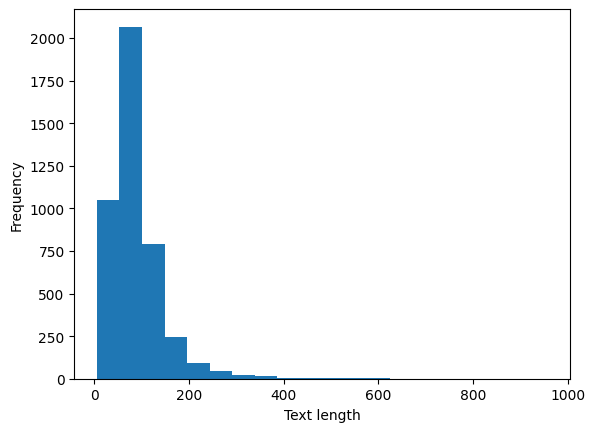

In [ ]:
import pandas as pd
from datasets import load_dataset

data = load_dataset("jziebura/polish_youth_slang_classification")

(
    pd.Series(data["train"]["tekst"])  # type: ignore
    .str.len()
    .plot.hist(
        bins=20,
        xlabel="Text length",
    )
);

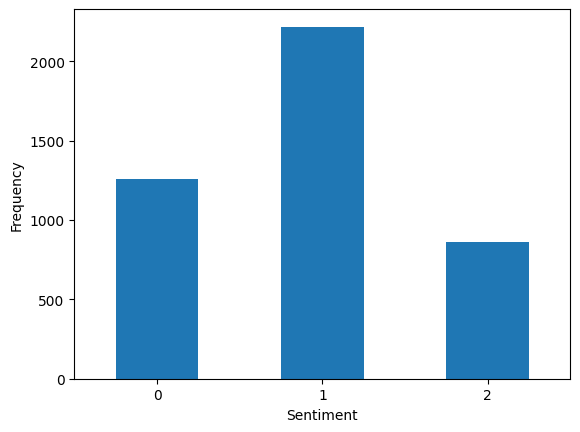

In [14]:
(
    pd.Series(data["train"]["sentyment"])  # type: ignore
    .value_counts()
    .sort_index()
    .plot.bar(
        xlabel="Sentiment",
        ylabel="Frequency",
        rot=0,
    )
);

In [ ]:
import os
import json
import time
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score

# --- CONFIGURATION ---
MODEL_PATH = "./herbert-slang/checkpoint-816"  # Directory where you saved the model
# If you saved checkpoints, it might be in "./herbert-slang/checkpoint-XXX"
# Check your folder. If MODEL_PATH contains 'config.json', it works.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16

# 1. LOAD MODEL & TOKENIZER
print(f"Loading model from {MODEL_PATH}")
tokenizer = AutoTokenizer.from_pretrained("allegro/herbert-base-cased")  # Tokenizer usually doesn't change
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(DEVICE)
model.eval()

# 2. MODEL SIZE (Parameter Count)
# We count all parameters (requires_grad=True/False doesn't matter for size)
param_count = sum(p.numel() for p in model.parameters())
print(f"Model Size: {param_count:,} parameters")


# 4. PREPARE TEST DATA
print("\nPreparing Test Set...")
dataset = load_dataset("jziebura/polish_youth_slang_classification")
dataset = dataset.rename_column("sentyment", "labels")


def tokenize(examples):
    return tokenizer(examples["tekst"], padding="max_length", truncation=True, max_length=512)


# Only process the test set
test_dataset = dataset["test"].map(tokenize, batched=True)
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


# 5. INFERENCE TIME & ACCURACY
print("Running Inference...")
all_preds = []
all_labels = []

start_time = time.time()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"]

        outputs = model(input_ids, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

end_time = time.time()
inference_time = end_time - start_time

# 6. REPORT
print("-" * 30)
print("FINAL RESULTS")
print("-" * 30)

# Metrics
acc = accuracy_score(all_labels, all_preds)
f1_weighted = f1_score(all_labels, all_preds, average="weighted")
f1_macro = f1_score(all_labels, all_preds, average="macro")

print(f"Accuracy:          {acc:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"F1 Score (Macro):    {f1_macro:.4f}")
print("-" * 30)

# Inference Speed
num_samples = len(all_labels)
print(f"Total Inference Time: {inference_time:.2f} s")
print(f"Time per Sample:      {(inference_time / num_samples) * 1000:.2f} ms")
print(f"Samples per Second:   {num_samples / inference_time:.2f}")

Loading model from ./herbert-slang/checkpoint-816...
Model Size: 124,445,187 parameters

Preparing Test Set...
Running Inference...
------------------------------
FINAL RESULTS
------------------------------
Accuracy:          0.7164
F1 Score (Weighted): 0.7166
F1 Score (Macro):    0.7044
------------------------------
Total Inference Time: 19.8433 seconds
Time per Sample:      36.54 ms
Samples per Second:   27.36


Loading logs from: ./herbert-slang/checkpoint-816/trainer_state.json


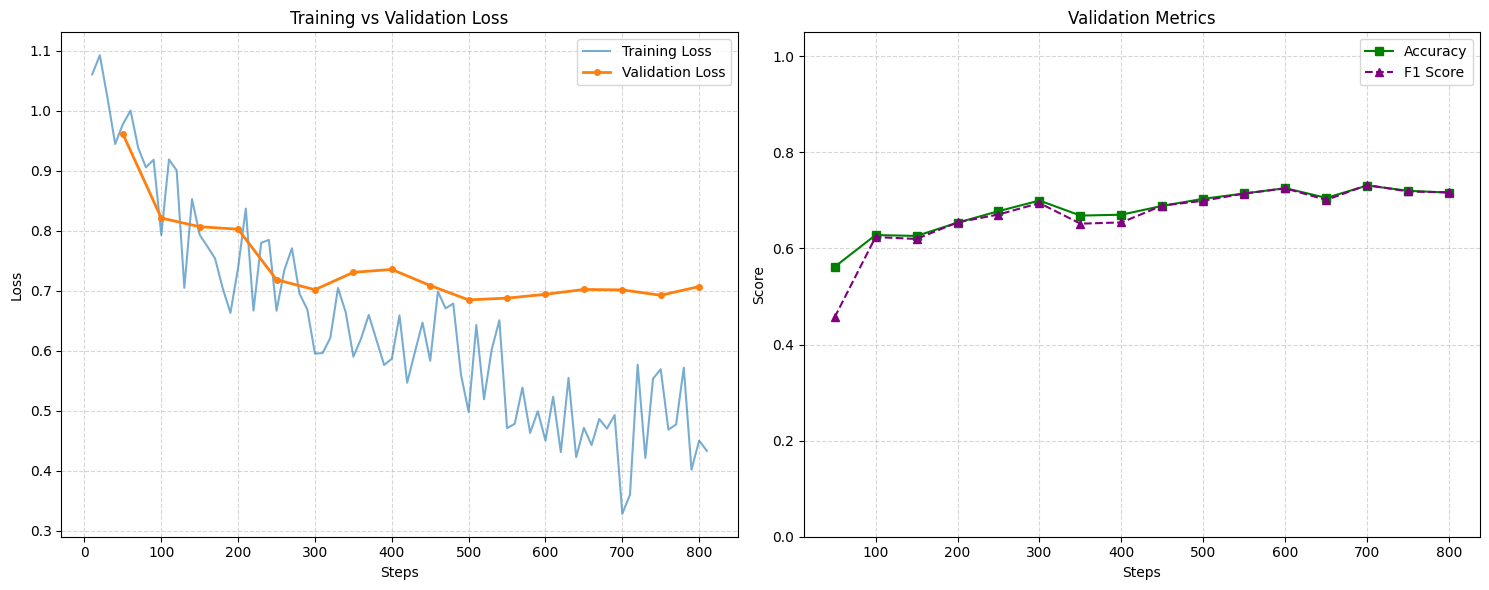

In [ ]:
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Path to your output directory
MODEL_DIR = "./herbert-slang/checkpoint-816"


def plot_training_curves(model_dir):
    # 1. Find the trainer_state.json file
    # It might be in the root of model_dir or inside a checkpoint folder
    json_path = os.path.join(model_dir, "trainer_state.json")

    # If not in root, check inside the latest checkpoint
    if not os.path.exists(json_path):
        subdirs = [d for d in os.listdir(model_dir) if d.startswith("checkpoint")]
        if subdirs:
            # Sort by step number to find the latest
            latest = sorted(subdirs, key=lambda x: int(x.split("-")[1]))[-1]
            json_path = os.path.join(model_dir, latest, "trainer_state.json")

    if not os.path.exists(json_path):
        print(f"❌ Error: Could not find 'trainer_state.json' in {model_dir}")
        return

    print(f"Loading logs from: {json_path}")
    with open(json_path, "r") as f:
        data = json.load(f)

    history = data["log_history"]

    # 2. Extract Data
    train_steps = []
    train_loss = []

    val_steps = []
    val_loss = []
    val_acc = []
    val_f1 = []

    for entry in history:
        # Training Loss usually comes with 'loss' key
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry["step"])
            train_loss.append(entry["loss"])

        # Validation Metrics usually come with 'eval_loss' key
        elif "eval_loss" in entry:
            val_steps.append(entry["step"])
            val_loss.append(entry["eval_loss"])

            # Extract accuracy/f1 if they exist
            if "eval_accuracy" in entry:
                val_acc.append(entry["eval_accuracy"])
            if "eval_f1" in entry:
                val_f1.append(entry["eval_f1"])

    # 3. Plotting
    plt.figure(figsize=(15, 6))

    # --- Plot 1: Loss Curve ---
    plt.subplot(1, 2, 1)
    plt.plot(train_steps, train_loss, label="Training Loss", color="#1f77b4", alpha=0.6)
    plt.plot(val_steps, val_loss, label="Validation Loss", color="#ff7f0e", linewidth=2, marker="o", markersize=4)
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)

    # --- Plot 2: Metrics (Accuracy/F1) ---
    if val_acc or val_f1:
        plt.subplot(1, 2, 2)
        if val_acc:
            plt.plot(val_steps, val_acc, label="Accuracy", color="green", marker="s")
        if val_f1:
            plt.plot(val_steps, val_f1, label="F1 Score", color="purple", linestyle="--", marker="^")

        plt.xlabel("Steps")
        plt.ylabel("Score")
        plt.title("Validation Metrics")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        # Set y-axis to strictly 0-1 if appropriate
        if max(val_acc + val_f1) <= 1.0:
            plt.ylim(0, 1.05)

    plt.tight_layout()
    plt.show()


# Run the function
plot_training_curves(MODEL_DIR)